In [18]:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



# 1. Introduction

Unsupervised Learning is a type of machine learning in which the model learns patterns from data without using labeled outputs. Unlike supervised learning, there are no predefined target values. The objective is to identify hidden structures, relationships, or groups within the data.

In this notebook, three popular clustering algorithms are implemented using the Iris dataset:

- K-Means Clustering
- Hierarchical Clustering
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

These algorithms are compared to understand how different clustering techniques group similar data points.

# 2: Import Libraries

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

# 3. What is Unsupervised Learning?

Unsupervised Learning is a type of machine learning in which the model learns patterns from data without using labeled outputs. The goal is to identify hidden structures, similarities, or groups within the dataset.

One of the most common unsupervised learning techniques is

**Clustering**, where similar data points are grouped together based on their features.

In this notebook, the **Iris Dataset** is used to demonstrate different clustering algorithms. Although the dataset contains species labels, they are not used during clustering. The algorithms group the flowers only based on their four features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The clustering algorithms implemented in this notebook are:

- K-Means Clustering
- Hierarchical Clustering
- DBSCAN Clustering

In [20]:
# Load the Iris Dataset
iris = load_iris()

In [21]:
# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Display first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [22]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Feature names
print("\nFeature Names:")
print(df.columns.tolist())

Dataset Shape: (150, 4)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [23]:
# Summary statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# 4. K-Means Clustering

K-Means is one of the most popular unsupervised learning algorithms used for clustering. It groups similar data points into a specified number of clusters (K) based on the distance between data points and cluster centers (centroids).

### How K-Means Works

1. Choose the number of clusters (K).
2. Randomly initialize K centroids.
3. Assign each data point to the nearest centroid.
4. Update the centroids by calculating the mean of each cluster.
5. Repeat the process until the centroids no longer change.

In this example, the Iris dataset is grouped into **3 clusters** because it contains three different flower species.

In [24]:
# Create K-Means model
kmeans = KMeans(n_clusters=3, random_state=42)

In [25]:
# Fit the model
kmeans.fit(df)

print("K-Means clustering completed successfully!")

K-Means clustering completed successfully!


In [26]:
# Cluster labels assigned to each sample
clusters = kmeans.labels_

# Display first 10 cluster labels
print(clusters[:10])

[1 1 1 1 1 1 1 1 1 1]


In [27]:
# Add cluster labels to the DataFrame
df["Cluster"] = clusters

# Display first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


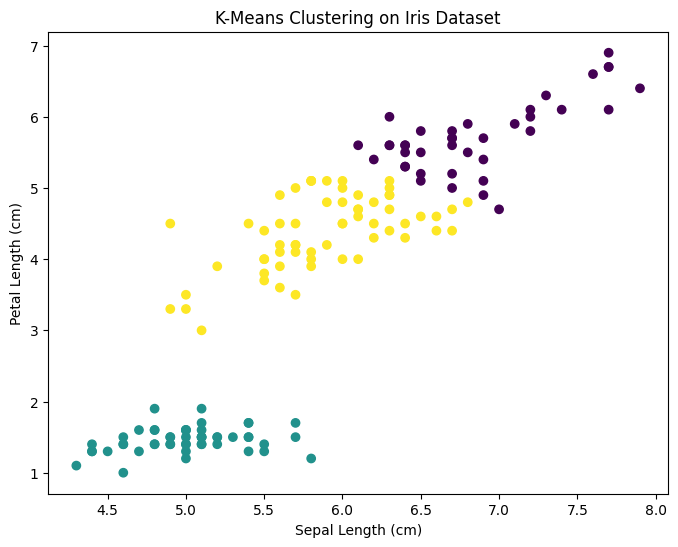

In [28]:
# Scatter Plot of K-Means Clusters

plt.figure(figsize=(8,6))

plt.scatter(
    df["sepal length (cm)"],
    df["petal length (cm)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")

plt.show()

# 5. Hierarchical Clustering

Hierarchical Clustering is an unsupervised learning algorithm that groups similar data points into a hierarchy of clusters. Unlike K-Means, it does not require randomly selecting initial cluster centers.

### How Hierarchical Clustering Works

1. Treat each data point as an individual cluster.
2. Find the two closest clusters.
3. Merge them into one cluster.
4. Repeat the process until all data points are grouped.

In this example, the Iris dataset is divided into **3 clusters** using Hierarchical Clustering.

In [29]:
# Create Hierarchical Clustering model
hierarchical = AgglomerativeClustering(n_clusters=3)

In [30]:
# Fit the model and predict clusters
hierarchical_clusters = hierarchical.fit_predict(df.iloc[:, :4])

print("Hierarchical Clustering completed successfully!")

Hierarchical Clustering completed successfully!


In [31]:
# Add cluster labels to the DataFrame
df["Hierarchical Cluster"] = hierarchical_clusters

# Display first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster,Hierarchical Cluster
0,5.1,3.5,1.4,0.2,1,1
1,4.9,3.0,1.4,0.2,1,1
2,4.7,3.2,1.3,0.2,1,1
3,4.6,3.1,1.5,0.2,1,1
4,5.0,3.6,1.4,0.2,1,1


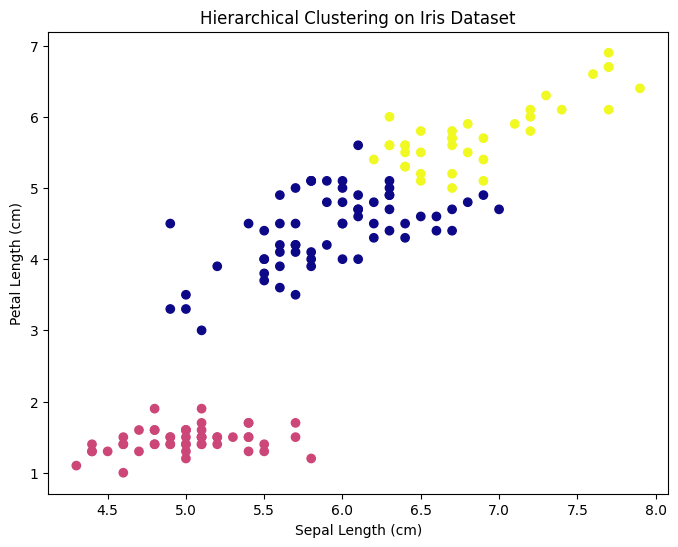

In [32]:
# Scatter Plot of Hierarchical Clustering

plt.figure(figsize=(8,6))

plt.scatter(
    df["sepal length (cm)"],
    df["petal length (cm)"],
    c=df["Hierarchical Cluster"],
    cmap="plasma"
)

plt.title("Hierarchical Clustering on Iris Dataset")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")

plt.show()

# 6. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised learning algorithm used to group data points based on their density. Unlike K-Means and Hierarchical Clustering, DBSCAN does not require specifying the number of clusters in advance.

### How DBSCAN Works

1. Select a data point.
2. Find all neighboring points within a specified distance (eps).
3. Form a cluster if the minimum number of neighboring points (min_samples) is reached.
4. Continue expanding the cluster by including nearby points.
5. Points that do not belong to any cluster are considered noise.

In this example, DBSCAN is applied to the Iris dataset to identify clusters based on the density of data points.

In [37]:
# Create DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)

In [38]:
# Fit the model and predict clusters
dbscan_clusters = dbscan.fit_predict(df.iloc[:, :4])

print("DBSCAN clustering completed successfully!")

DBSCAN clustering completed successfully!


In [39]:
# Add DBSCAN cluster labels
df["DBSCAN Cluster"] = dbscan_clusters

# Display first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster,Hierarchical Cluster,DBSCAN Cluster
0,5.1,3.5,1.4,0.2,1,1,0
1,4.9,3.0,1.4,0.2,1,1,0
2,4.7,3.2,1.3,0.2,1,1,0
3,4.6,3.1,1.5,0.2,1,1,0
4,5.0,3.6,1.4,0.2,1,1,0


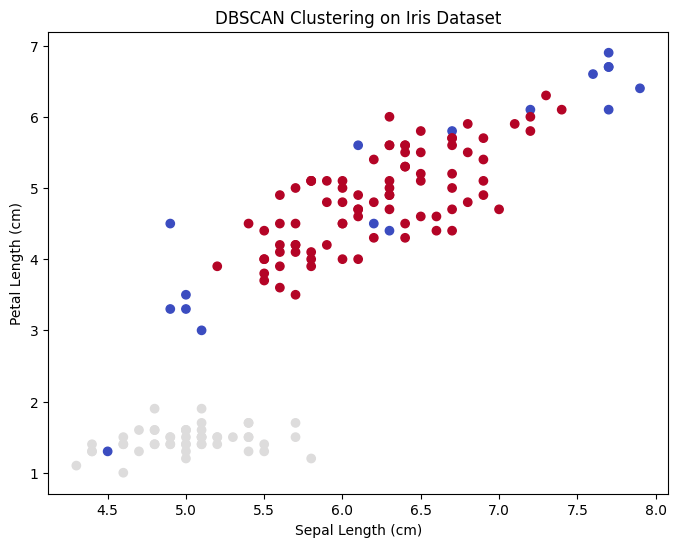

In [40]:
# Scatter Plot of DBSCAN Clustering

plt.figure(figsize=(8,6))

plt.scatter(
    df["sepal length (cm)"],
    df["petal length (cm)"],
    c=df["DBSCAN Cluster"],
    cmap="coolwarm"
)

plt.title("DBSCAN Clustering on Iris Dataset")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")

plt.show()

# 7. Comparison of Clustering Algorithms

In this notebook, three clustering algorithms were implemented using the Iris dataset. Each algorithm has its own characteristics and is suitable for different types of data.

### K-Means Clustering
- Groups data into a fixed number of clusters.
- Simple and fast to implement.
- The number of clusters must be specified before training.

### Hierarchical Clustering
- Creates clusters by merging similar data points step by step.
- Easy to understand and visualize.
- Can be slower when working with large datasets.

### DBSCAN Clustering
- Groups data based on the density of data points.
- Does not require specifying the number of clusters.
- Can identify noise or outlier data points.
- Performance depends on the values of **eps** and **min_samples**.

### Summary

- **K-Means** is suitable when the number of clusters is already known.
- **Hierarchical Clustering** is useful for understanding relationships between data points.
- **DBSCAN** is effective for detecting clusters of different shapes and identifying outliers.

Each clustering algorithm has its own advantages, and the choice of algorithm depends on the nature of the dataset and the problem being solved.

In [41]:
print("K-Means Clusters:", len(set(df["Cluster"])))
print("Hierarchical Clusters:", len(set(df["Hierarchical Cluster"])))
print("DBSCAN Clusters:", len(set(df["DBSCAN Cluster"])))

K-Means Clusters: 3
Hierarchical Clusters: 3
DBSCAN Clusters: 3


# 8. Conclusion

In this notebook, three popular clustering algorithms were implemented using the Iris dataset.

- K-Means Clustering
- Hierarchical Clustering
- DBSCAN Clustering

These algorithms grouped similar flower samples based on their features without using the species labels. The implementation helped in understanding the basic concepts of unsupervised learning and how different clustering techniques identify patterns within data.

Overall, this project provided a practical introduction to clustering techniques using Python and Scikit-learn.